# Thesis — Improved Training Pipeline (Incremental Ablation)

**Goal:** without changing the dataset or the core dual-branch idea, stack proven
training improvements onto the best merged-dataset architecture and measure the
contribution of each, one at a time.

**Dataset:** merged Derm7pt + MILK10k (5 classes: BCC, MEL, MISC, NV, SK).

**Base architecture (A0):** Mul-Fusion = `DualBranchElementwiseFusion(fusion='mul')` —
the best performer on the merged set (0.804 acc / 0.743 F1-macro in Chapter 4).

**Cumulative ablation** (each step keeps everything before it and adds one technique):

| Step | Adds |
|------|------|
| A0 | Baseline Mul-Fusion (Adam, weighted CE) |
| A1 | + AdamW + linear warmup → cosine |
| A2 | + label smoothing (0.1) |
| A3 | + Focal Loss (γ=2.0, α=class weights) |
| A4 | + MixUp (paired, Beta(0.4,0.4)) |
| A5 | + dermoscopy-biased auxiliary loss |
| A6 | + SWA (stochastic weight averaging) |
| A7 | + contrastive pretraining (cross-modal SimCLR init) |

Run the **smoke test** first (`SMOKE_TEST = True` in §2) to validate plumbing in
~15–25 min, then flip to `False` for the full overnight run.

## 1 — Setup: imports, merged data, loaders

In [2]:
import os, copy, time, math, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.swa_utils import AveragedModel, SWALR

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score,
    balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef, log_loss
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
print(f'Device: {device} | PyTorch {torch.__version__}')

DERM7PT_DIR = Path('dataset') / 'Derm7pt'
MILK_DIR    = Path('dataset') / 'milk10k'

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Device: cuda | PyTorch 2.6.0+cu124


In [3]:
# ── Merged dataframe: Derm7pt + MILK10k → 5 classes ──────────────────────────
# Derm7pt
derm_df = pd.read_csv(DERM7PT_DIR / 'meta' / 'meta.csv')
derm_df['clinic_path'] = derm_df['clinic'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['derm_path']   = derm_df['derm'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['diagnosis']   = derm_df['diagnosis'].str.strip().str.lower()
diagnosis_groups = {
    'melanoma': 'MEL', 'melanoma (less than 0.76 mm)': 'MEL', 'melanoma (in situ)': 'MEL',
    'melanoma (0.76 to 1.5 mm)': 'MEL', 'melanoma (more than 1.5 mm)': 'MEL',
    'melanoma metastasis': 'MEL',
    'clark nevus': 'NV', 'reed or spitz nevus': 'NV', 'dermal nevus': 'NV',
    'blue nevus': 'NV', 'congenital nevus': 'NV', 'combined nevus': 'NV',
    'recurrent nevus': 'NV',
    'basal cell carcinoma': 'BCC',
    'seborrheic keratosis': 'SK',
    'lentigo': 'MISC', 'dermatofibroma': 'MISC', 'vascular lesion': 'MISC',
    'melanosis': 'MISC', 'miscellaneous': 'MISC',
}
derm_df['diagnosis_group'] = derm_df['diagnosis'].map(diagnosis_groups)

class_names = sorted(derm_df['diagnosis_group'].dropna().unique())   # ['BCC','MEL','MISC','NV','SK']
label_map   = {name: i for i, name in enumerate(class_names)}

# MILK10k
milk_meta = pd.read_csv(MILK_DIR / 'MILK10k_Training_Metadata.csv')
milk_gt   = pd.read_csv(MILK_DIR / 'MILK10k_Training_GroundTruth.csv')
milk_class_map = {'MEL': 'MEL', 'NV': 'NV', 'BCC': 'BCC', 'BKL': 'SK', 'DF': 'MISC', 'VASC': 'MISC'}
drop_classes   = {'AKIEC', 'SCCKA', 'INF', 'BEN_OTH', 'MAL_OTH'}
gt_cols = [c for c in milk_gt.columns if c != 'lesion_id']
milk_gt['raw_class'] = milk_gt[gt_cols].idxmax(axis=1)
milk_gt = milk_gt[~milk_gt['raw_class'].isin(drop_classes)].copy()
milk_gt['diagnosis_group'] = milk_gt['raw_class'].map(milk_class_map)
clinic_meta = (milk_meta[milk_meta['image_type'] == 'clinical: close-up']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'clinic_isic'}))
derm_meta   = (milk_meta[milk_meta['image_type'] == 'dermoscopic']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'derm_isic'}))
paths = clinic_meta.merge(derm_meta, on='lesion_id')
milk_df = milk_gt[['lesion_id', 'diagnosis_group']].merge(paths, on='lesion_id')
milk_df['clinic_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['clinic_isic']}.jpg"), axis=1)
milk_df['derm_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['derm_isic']}.jpg"), axis=1)
milk_df['source'] = 'MILK10k'

# Combine
derm7_clean = derm_df[['clinic_path', 'derm_path', 'diagnosis_group']].copy()
derm7_clean['source'] = 'Derm7pt'
combined = pd.concat(
    [derm7_clean, milk_df[['clinic_path', 'derm_path', 'diagnosis_group', 'source']]],
    ignore_index=True)
combined['label'] = combined['diagnosis_group'].map(label_map)
df = combined.dropna(subset=['label']).reset_index(drop=True)
df['label'] = df['label'].astype(int)
print(f'Merged: {len(df)} samples | {len(class_names)} classes {class_names}')
print(df['diagnosis_group'].value_counts().to_string())

Merged: 5372 samples | 5 classes ['BCC', 'MEL', 'MISC', 'NV', 'SK']
diagnosis_group
BCC     2564
NV      1321
MEL      702
SK       589
MISC     196


In [4]:
class SkinLesionDualDataset(Dataset):
    """Returns (clinic_img, derm_img, label) for each sample."""
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clinic_img = Image.open(row['clinic_path']).convert('RGB')
        derm_img   = Image.open(row['derm_path']).convert('RGB')
        if self.transform:
            clinic_img = self.transform(clinic_img)
            derm_img   = self.transform(derm_img)
        return clinic_img, derm_img, torch.tensor(row['label'], dtype=torch.long)


train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [5]:
# ── Stratified 70/15/15 split + class weights ────────────────────────────────
def build_dataset(df_in, name):
    labels  = df_in['label'].values.astype(int)
    indices = np.arange(len(df_in))
    tr, tmp = train_test_split(indices, test_size=0.30, stratify=labels, random_state=SEED)
    va, te  = train_test_split(tmp,     test_size=0.50, stratify=labels[tmp], random_state=SEED)
    train_labels = labels[tr]
    class_counts = np.bincount(train_labels, minlength=len(class_names))
    safe_counts  = np.where(class_counts == 0, 1, class_counts)
    sample_w     = (1.0 / safe_counts)[train_labels]
    loss_w       = torch.tensor(
        [len(train_labels) / (len(class_names) * c) if c > 0 else 0.0 for c in class_counts],
        dtype=torch.float32).to(device)
    return {
        'name': name, 'df': df_in,
        'train_idx': tr, 'val_idx': va, 'test_idx': te,
        'sample_weights': sample_w, 'loss_weights': loss_w,
        'class_counts': class_counts,
    }

MERGED = build_dataset(df, 'merged')
print(f'{MERGED["name"]:>8s}: train={len(MERGED["train_idx"])} '
      f'val={len(MERGED["val_idx"])} test={len(MERGED["test_idx"])} '
      f'| train class counts = {MERGED["class_counts"].tolist()}')

# ── DataLoaders ──────────────────────────────────────────────────────────────
_NUM_WORKERS = 0 if device.type in ('mps', 'cpu') or os.name == 'nt' else min(8, os.cpu_count() or 4)
_PIN_MEMORY  = device.type == 'cuda'

def make_loaders(batch_size, ds):
    """Return (train_loader, val_loader, test_loader, test_ds) for a dataset dict.
    train_loader uses drop_last=True so BatchNorm1d / MixUp never see a size-1 batch."""
    train_ds = SkinLesionDualDataset(ds['df'].iloc[ds['train_idx']], train_transform)
    val_ds   = SkinLesionDualDataset(ds['df'].iloc[ds['val_idx']],   val_transform)
    test_ds  = SkinLesionDualDataset(ds['df'].iloc[ds['test_idx']],  val_transform)
    samp = WeightedRandomSampler(ds['sample_weights'], len(ds['sample_weights']), replacement=True)
    kw = dict(num_workers=_NUM_WORKERS, pin_memory=_PIN_MEMORY,
              persistent_workers=(_NUM_WORKERS > 0))
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=samp, drop_last=True, **kw)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw)
    return train_loader, val_loader, test_loader, test_ds

  merged: train=3760 val=806 test=806 | train class counts = [1795, 491, 137, 925, 412]


## 2 — Infrastructure: backbone, hyperparameters, run-scale config

In [6]:
class ResNet50Backbone(nn.Module):
    """ResNet50 feature extractor — returns spatial feature maps [B, 2048, 7, 7]."""
    def __init__(self, pretrained=True):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4)

    def forward(self, x):
        return self.features(x)


# ── Fixed hyperparameters (match Chapter 4) ──────────────────────────────────
LR             = 0.000750
DROPOUT        = 0.32
WEIGHT_DECAY   = 0.000957
BATCH_SIZE     = 64
FINAL_EPOCHS   = 60
PATIENCE       = 20
UNFREEZE_EPOCH = 5
GRAD_CLIP      = 1.0

# ── New knobs for the improvements ───────────────────────────────────────────
WARMUP_EPOCHS     = 3
LABEL_SMOOTHING   = 0.1
FOCAL_GAMMA       = 2.0
MIXUP_ALPHA       = 0.4
MIXUP_PROB        = 0.5
AUX_WEIGHT        = 0.3
SWA_START_FRAC    = 0.75
CONTRASTIVE_EPOCHS = 30
CONTRASTIVE_TEMP  = 0.5
PROJ_DIM          = 128


class EarlyStopping:
    """Stops training if val_loss doesn't improve for `patience` consecutive epochs."""
    def __init__(self, patience=20, min_delta=1e-4):
        self.patience = patience; self.min_delta = min_delta
        self.counter = 0; self.best_loss = float('inf')
        self.best_state = None; self.stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [7]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  RUN-SCALE CONFIG — set SMOKE_TEST=True first to validate the whole chain   ║
# ╚══════════════════════════════════════════════════════════════════════════╝
SMOKE_TEST = False       # True → tiny/fast validation run; False → full overnight run

if SMOKE_TEST:
    SUBSET_FRAC        = 0.15   # fraction of each split to keep
    EPOCHS_OVERRIDE    = 4      # max epochs per ablation step
    CONTRASTIVE_EPOCHS = 2
    PATIENCE           = 99     # effectively disable early stop during smoke test
else:
    SUBSET_FRAC        = 1.0
    EPOCHS_OVERRIDE    = None   # use FINAL_EPOCHS

EPOCHS = EPOCHS_OVERRIDE if EPOCHS_OVERRIDE else FINAL_EPOCHS


def subset_ds(ds, frac):
    """Stratified down-sample of each split; recompute sampling/loss weights."""
    if frac >= 1.0:
        return ds
    labels_all = ds['df']['label'].values.astype(int)
    def sub(idx):
        lab = labels_all[idx]
        keep, _ = train_test_split(idx, train_size=frac, stratify=lab, random_state=SEED)
        return keep
    out = dict(ds)
    out['train_idx'] = sub(ds['train_idx'])
    out['val_idx']   = sub(ds['val_idx'])
    out['test_idx']  = sub(ds['test_idx'])
    tl = labels_all[out['train_idx']]
    cc = np.bincount(tl, minlength=len(class_names))
    safe = np.where(cc == 0, 1, cc)
    out['sample_weights'] = (1.0 / safe)[tl]
    out['loss_weights']   = torch.tensor(
        [len(tl) / (len(class_names) * c) if c > 0 else 0.0 for c in cc],
        dtype=torch.float32).to(device)
    out['class_counts'] = cc
    return out

DS = subset_ds(MERGED, SUBSET_FRAC)
print(f'Run scale: SMOKE_TEST={SMOKE_TEST} | epochs={EPOCHS} | '
      f'train={len(DS["train_idx"])} val={len(DS["val_idx"])} test={len(DS["test_idx"])}')

Run scale: SMOKE_TEST=False | epochs=60 | train=3760 val=806 test=806


## 3 — New components

Focal loss (soft-target capable), paired MixUp, the flexible model (aux head +
projection heads), NT-Xent contrastive loss, loss/optimizer factories, the
improved train/validate loops, contrastive pretraining, and the unified driver.

In [8]:
class FocalLoss(nn.Module):
    """Focal loss that accepts HARD [B] or SOFT [B,C] targets, with optional
    label smoothing and per-class alpha weights.

        loss = -Σ_c  α_c · (1 - p_c)^γ · q_c · log p_c

    where q is the (optionally smoothed) target distribution. γ=0 reduces to
    (weighted, smoothed) cross-entropy."""
    def __init__(self, gamma=2.0, alpha=None, label_smoothing=0.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha               # tensor [C] or None
        self.ls = label_smoothing
        self.reduction = reduction

    def forward(self, logits, target):
        C = logits.size(1)
        logp = F.log_softmax(logits, dim=1)
        p = logp.exp()
        if target.dim() == 1:
            q = F.one_hot(target, C).float()
        else:
            q = target.float()
        if self.ls > 0:
            q = q * (1 - self.ls) + self.ls / C
        loss_terms = -((1 - p) ** self.gamma) * q * logp        # [B, C]
        if self.alpha is not None:
            loss_terms = loss_terms * self.alpha.view(1, -1)
        loss = loss_terms.sum(dim=1)                             # [B]
        if self.reduction == 'mean':
            return loss.mean()
        if self.reduction == 'sum':
            return loss.sum()
        return loss

In [9]:
def mixup_dual_batch(clinic, derm, labels, num_classes, alpha):
    """Paired MixUp: SAME lambda + permutation applied to both modalities so the
    (clinic, derm) lesion pairing is preserved. Returns mixed images and a SOFT
    [B, C] target."""
    lam = float(np.random.beta(alpha, alpha))
    perm = torch.randperm(clinic.size(0), device=clinic.device)
    clinic_m = lam * clinic + (1 - lam) * clinic[perm]
    derm_m   = lam * derm   + (1 - lam) * derm[perm]
    y = F.one_hot(labels, num_classes).float()
    target = lam * y + (1 - lam) * y[perm]
    return clinic_m, derm_m, target

In [10]:
class ImprovedDualBranchFusion(nn.Module):
    """Flexible Mul/Add-fusion dual-branch model used by every ablation step.

    forward() -> (main_logits, aux_logits)   # aux is None unless use_aux=True
                                              # so eval harness `logits, _ = model(...)` still works
    encode()  -> (pooled_clinic, pooled_derm) [B, 2048]   # for contrastive
    project() -> (z_clinic, z_derm) L2-normalized [B, proj_dim]   # NT-Xent
    """
    def __init__(self, num_classes=5, dropout=0.32, fusion='mul', pretrained=True,
                 use_aux=False, use_projection=False, proj_dim=128):
        super().__init__()
        assert fusion in ('add', 'mul')
        self.fusion = fusion
        self.use_aux = use_aux
        self.use_projection = use_projection
        self.resnet_clinic = ResNet50Backbone(pretrained=pretrained)
        self.resnet_derm   = ResNet50Backbone(pretrained=pretrained)
        self.post_fuse = nn.Sequential(nn.BatchNorm2d(2048), nn.ReLU(inplace=True))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(2048, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(512, num_classes))
        if use_aux:
            self.aux_head = nn.Sequential(
                nn.Linear(2048, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
                nn.Dropout(dropout), nn.Linear(256, num_classes))
        if use_projection:
            self.proj_clinic = nn.Sequential(
                nn.Linear(2048, 2048), nn.ReLU(inplace=True), nn.Linear(2048, proj_dim))
            self.proj_derm = nn.Sequential(
                nn.Linear(2048, 2048), nn.ReLU(inplace=True), nn.Linear(2048, proj_dim))

    def _freeze_backbones(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.parameters(): p.requires_grad = False
            for p in m.features[7].parameters(): p.requires_grad = True

    def unfreeze_resnets(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.features[6].parameters(): p.requires_grad = True

    def encode(self, clinic_img, derm_img):
        fc = self.pool(self.resnet_clinic(clinic_img)).flatten(1)
        fd = self.pool(self.resnet_derm(derm_img)).flatten(1)
        return fc, fd

    def project(self, clinic_img, derm_img):
        fc, fd = self.encode(clinic_img, derm_img)
        return F.normalize(self.proj_clinic(fc), dim=1), F.normalize(self.proj_derm(fd), dim=1)

    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        fused = feat_c + feat_d if self.fusion == 'add' else feat_c * feat_d
        x = self.pool(self.post_fuse(fused)).flatten(1)
        main = self.classifier(x)
        aux = self.aux_head(self.pool(feat_d).flatten(1)) if self.use_aux else None
        return main, aux

In [11]:
def nt_xent_loss(z_clinic, z_derm, temperature=0.5):
    """Cross-modal NT-Xent (SimCLR). Positive pair = (clinic_i, derm_i) of the
    same lesion; all other 2B-2 samples in the batch are negatives."""
    B = z_clinic.size(0)
    z = torch.cat([z_clinic, z_derm], dim=0)              # [2B, D]
    sim = torch.mm(z, z.t()) / temperature                # [2B, 2B]
    sim.masked_fill_(torch.eye(2 * B, dtype=torch.bool, device=z.device), float('-inf'))
    targets = (torch.arange(2 * B, device=z.device) + B) % (2 * B)
    return F.cross_entropy(sim, targets)

In [12]:
def build_loss(config, loss_weights):
    """Loss factory. 'ce'/'ls' use nn.CrossEntropyLoss (hard targets, A0–A2 never
    MixUp); 'focal' uses the soft-target-capable FocalLoss (A3+ where MixUp lives)."""
    t = config['loss']
    ls = config.get('label_smoothing', 0.0)
    if t == 'ce':
        return nn.CrossEntropyLoss(weight=loss_weights)
    if t == 'ls':
        return nn.CrossEntropyLoss(weight=loss_weights, label_smoothing=ls)
    if t == 'focal':
        return FocalLoss(gamma=FOCAL_GAMMA, alpha=loss_weights, label_smoothing=ls)
    raise ValueError(f'unknown loss {t}')


def make_opt_sched(params, opt_name, base_lr, phase_epochs, warmup_epochs):
    """Build optimizer + per-phase scheduler. warmup_epochs>0 → linear warmup then
    cosine; else plain cosine annealing over phase_epochs."""
    params = list(params)
    if opt_name == 'adamw':
        opt = optim.AdamW(params, lr=base_lr, weight_decay=WEIGHT_DECAY)
    else:
        opt = optim.Adam(params, lr=base_lr, weight_decay=WEIGHT_DECAY)
    if warmup_epochs and warmup_epochs > 0:
        def lr_lambda(ep):
            if ep < warmup_epochs:
                return (ep + 1) / warmup_epochs
            prog = (ep - warmup_epochs) / max(1, phase_epochs - warmup_epochs)
            return 0.5 * (1 + math.cos(math.pi * prog))
        sched = optim.lr_scheduler.LambdaLR(opt, lr_lambda)
    else:
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, phase_epochs))
    return opt, sched

In [13]:
def train_one_epoch_improved(model, loader, optimizer, criterion, grad_clip,
                             num_classes, mixup_alpha=0.0, mixup_prob=0.0, aux_weight=0.0):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for clinic, derm, labels in loader:
        clinic, derm, labels = clinic.to(device), derm.to(device), labels.to(device)
        optimizer.zero_grad()
        if mixup_prob > 0 and np.random.rand() < mixup_prob:
            clinic, derm, target = mixup_dual_batch(clinic, derm, labels, num_classes, mixup_alpha)
        else:
            target = labels
        main_logits, aux_logits = model(clinic, derm)
        loss = criterion(main_logits, target)
        if aux_weight > 0 and aux_logits is not None:
            loss = loss + aux_weight * criterion(aux_logits, target)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * clinic.size(0)
        hard = target.argmax(1) if target.dim() == 2 else target
        correct += main_logits.argmax(1).eq(hard).sum().item()
        total   += clinic.size(0)
    return total_loss / total, correct / total


def validate_improved(model, loader, criterion):
    """Validation always uses hard labels, no MixUp, no aux term."""
    eval_crit = criterion
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for clinic, derm, labels in loader:
            clinic, derm, labels = clinic.to(device), derm.to(device), labels.to(device)
            main_logits, _ = model(clinic, derm)
            loss = eval_crit(main_logits, labels)
            total_loss += loss.item() * clinic.size(0)
            correct += main_logits.argmax(1).eq(labels).sum().item()
            total   += clinic.size(0)
    return total_loss / total, correct / total


def update_bn_dual(loader, model):
    """Recompute BatchNorm running stats for a dual-input model (torch's update_bn
    assumes a single input tensor). Uses clean (non-MixUp) augmented training data."""
    momenta = {}
    for module in model.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.reset_running_stats()
            momenta[module] = module.momentum
            module.momentum = None
    if not momenta:
        return
    was_training = model.training
    model.train()
    with torch.no_grad():
        for clinic, derm, _ in loader:
            model(clinic.to(device), derm.to(device))
    for bn, m in momenta.items():
        bn.momentum = m
    model.train(was_training)

In [14]:
def contrastive_pretrain(ds, ckpt_out, epochs):
    """Cross-modal SimCLR pretraining of the two backbones. Saves backbone state
    dicts only (projection heads discarded)."""
    train_loader, *_ = make_loaders(BATCH_SIZE, ds)
    model = ImprovedDualBranchFusion(num_classes=len(class_names), dropout=DROPOUT,
                                     fusion='mul', pretrained=True, use_projection=True).to(device)
    for p in model.parameters():
        p.requires_grad = True
    params = (list(model.resnet_clinic.parameters()) + list(model.resnet_derm.parameters())
              + list(model.proj_clinic.parameters()) + list(model.proj_derm.parameters()))
    opt = optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    start = time.time()
    for epoch in range(epochs):
        model.train()
        tot, n = 0.0, 0
        for clinic, derm, _ in train_loader:
            clinic, derm = clinic.to(device), derm.to(device)
            opt.zero_grad()
            zc, zd = model.project(clinic, derm)
            loss = nt_xent_loss(zc, zd, CONTRASTIVE_TEMP)
            loss.backward()
            nn.utils.clip_grad_norm_(params, GRAD_CLIP)
            opt.step()
            tot += loss.item() * clinic.size(0); n += clinic.size(0)
        sched.step()
        print(f'  [contrastive] ep {epoch+1:2d}/{epochs} | loss {tot/n:.4f}')
    torch.save({'resnet_clinic': model.resnet_clinic.state_dict(),
                'resnet_derm':   model.resnet_derm.state_dict()}, ckpt_out)
    print(f'  Saved contrastive backbones -> {ckpt_out} ({(time.time()-start)/60:.1f} min)')
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return ckpt_out

In [15]:
def train_model(config, ds, total_epochs, contrastive_ckpt=None):
    """Unified driver for one ablation step. Honors freeze→unfreeze@5 schedule;
    toggles optimizer / scheduler / loss / mixup / aux / SWA / contrastive-init."""
    NC = len(class_names)
    train_loader, val_loader, _, _ = make_loaders(BATCH_SIZE, ds)

    model = ImprovedDualBranchFusion(num_classes=NC, dropout=DROPOUT, fusion=config['fusion'],
                                     pretrained=True, use_aux=config['use_aux']).to(device)
    if config.get('pretrained_init') and contrastive_ckpt and Path(contrastive_ckpt).exists():
        bb = torch.load(contrastive_ckpt, map_location=device, weights_only=False)
        model.resnet_clinic.load_state_dict(bb['resnet_clinic'])
        model.resnet_derm.load_state_dict(bb['resnet_derm'])
        print(f'  Loaded contrastive backbones from {contrastive_ckpt}')

    model._freeze_backbones()
    criterion = build_loss(config, ds['loss_weights'])
    warmup = WARMUP_EPOCHS if config['schedule'] == 'warmup_cosine' else 0
    opt, sched = make_opt_sched(filter(lambda p: p.requires_grad, model.parameters()),
                                config['optimizer'], LR, UNFREEZE_EPOCH, warmup)

    use_swa   = config['use_swa']
    swa_model = AveragedModel(model) if use_swa else None
    swa_start = int(SWA_START_FRAC * total_epochs)
    swa_sched = None

    mixup_alpha = MIXUP_ALPHA if config['use_mixup'] else 0.0
    mixup_prob  = MIXUP_PROB  if config['use_mixup'] else 0.0
    aux_weight  = AUX_WEIGHT  if config['use_aux']  else 0.0

    early_stop = EarlyStopping(patience=PATIENCE)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    early_stop_epoch = None
    start = time.time()

    for epoch in range(total_epochs):
        if epoch == UNFREEZE_EPOCH:
            model.unfreeze_resnets()
            opt, sched = make_opt_sched(model.parameters(), config['optimizer'],
                                        LR / 4, total_epochs - UNFREEZE_EPOCH, 0)
            if use_swa:
                swa_sched = SWALR(opt, swa_lr=LR / 8)
            print(f'  Epoch {epoch+1}: unfroze layer3, lr -> {LR/4:.2e}')

        tr_loss, tr_acc = train_one_epoch_improved(
            model, train_loader, opt, criterion, GRAD_CLIP, NC,
            mixup_alpha, mixup_prob, aux_weight)
        va_loss, va_acc = validate_improved(model, val_loader, criterion)

        in_swa = use_swa and epoch >= swa_start
        if in_swa:
            swa_model.update_parameters(model)
            if swa_sched is not None: swa_sched.step()
        else:
            sched.step()

        history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc);   history['val_acc'].append(va_acc)

        # Early stop only when NOT using SWA (SWA must reach the averaging phase)
        if not use_swa:
            early_stop(va_loss, model)
        print(f'  Ep {epoch+1:2d}/{total_epochs} | train {tr_loss:.4f}/{tr_acc:.4f} | '
              f'val {va_loss:.4f}/{va_acc:.4f}'
              + (f' | SWA' if in_swa else f' | es {early_stop.counter}/{PATIENCE}'))
        if (not use_swa) and early_stop.stop:
            early_stop_epoch = epoch + 1
            print(f'  -> Early stop at epoch {early_stop_epoch}. Restoring best weights.')
            early_stop.restore(model)
            break

    if use_swa:
        update_bn_dual(train_loader, swa_model)
        save_state = swa_model.module.state_dict()
        best_val = min(history['val_loss'])
    else:
        early_stop.restore(model)
        save_state = model.state_dict()
        best_val = early_stop.best_loss

    torch.save({'model_state_dict': save_state, 'fusion': config['fusion'],
                'use_aux': config['use_aux'], 'class_names': class_names,
                'label_map': label_map, 'history': history,
                'best_val_loss': best_val, 'early_stop_epoch': early_stop_epoch,
                'config': {k: v for k, v in config.items() if k != 'ckpt'}},
               config['ckpt'])
    print(f"  {config['name']}: done in {(time.time()-start)/60:.1f} min | "
          f"best val loss {best_val:.4f} | saved {config['ckpt']}")
    del model
    if use_swa: del swa_model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return history

## 4 — Ablation configs + driver

Each config is **cumulative** — it carries every flag from the previous step and
turns on one more. The driver skips any step whose checkpoint already exists, so
the long run is resumable across kernel restarts.

In [16]:
SUFFIX = '_smoke' if SMOKE_TEST else ''
def _ck(stem): return f'{stem}{SUFFIX}.pth'

ABLATIONS = [
    {'name': 'A0_baseline',     'ckpt': _ck('improved_A0_baseline_merged'),
     'fusion': 'mul', 'optimizer': 'adam',  'schedule': 'cosine',
     'loss': 'ce',    'label_smoothing': 0.0, 'use_mixup': False,
     'use_aux': False, 'use_swa': False, 'pretrained_init': False},

    {'name': 'A1_adamw_warmup', 'ckpt': _ck('improved_A1_adamw_warmup_merged'),
     'fusion': 'mul', 'optimizer': 'adamw', 'schedule': 'warmup_cosine',
     'loss': 'ce',    'label_smoothing': 0.0, 'use_mixup': False,
     'use_aux': False, 'use_swa': False, 'pretrained_init': False},

    {'name': 'A2_labelsmooth',  'ckpt': _ck('improved_A2_labelsmooth_merged'),
     'fusion': 'mul', 'optimizer': 'adamw', 'schedule': 'warmup_cosine',
     'loss': 'ls',    'label_smoothing': LABEL_SMOOTHING, 'use_mixup': False,
     'use_aux': False, 'use_swa': False, 'pretrained_init': False},

    {'name': 'A3_focal',        'ckpt': _ck('improved_A3_focal_merged'),
     'fusion': 'mul', 'optimizer': 'adamw', 'schedule': 'warmup_cosine',
     'loss': 'focal', 'label_smoothing': LABEL_SMOOTHING, 'use_mixup': False,
     'use_aux': False, 'use_swa': False, 'pretrained_init': False},

    {'name': 'A4_mixup',        'ckpt': _ck('improved_A4_mixup_merged'),
     'fusion': 'mul', 'optimizer': 'adamw', 'schedule': 'warmup_cosine',
     'loss': 'focal', 'label_smoothing': LABEL_SMOOTHING, 'use_mixup': True,
     'use_aux': False, 'use_swa': False, 'pretrained_init': False},

    {'name': 'A5_aux',          'ckpt': _ck('improved_A5_aux_merged'),
     'fusion': 'mul', 'optimizer': 'adamw', 'schedule': 'warmup_cosine',
     'loss': 'focal', 'label_smoothing': LABEL_SMOOTHING, 'use_mixup': True,
     'use_aux': True,  'use_swa': False, 'pretrained_init': False},

    {'name': 'A6_swa',          'ckpt': _ck('improved_A6_swa_merged'),
     'fusion': 'mul', 'optimizer': 'adamw', 'schedule': 'warmup_cosine',
     'loss': 'focal', 'label_smoothing': LABEL_SMOOTHING, 'use_mixup': True,
     'use_aux': True,  'use_swa': True,  'pretrained_init': False},

    {'name': 'A7_contrastive',  'ckpt': _ck('improved_A7_contrastive_merged'),
     'fusion': 'mul', 'optimizer': 'adamw', 'schedule': 'warmup_cosine',
     'loss': 'focal', 'label_smoothing': LABEL_SMOOTHING, 'use_mixup': True,
     'use_aux': True,  'use_swa': True,  'pretrained_init': True},
]
for c in ABLATIONS:
    print(f"{c['name']:<18s} opt={c['optimizer']:<5s} sched={c['schedule']:<13s} "
          f"loss={c['loss']:<5s} mixup={int(c['use_mixup'])} aux={int(c['use_aux'])} "
          f"swa={int(c['use_swa'])} contrast={int(c['pretrained_init'])}")

A0_baseline        opt=adam  sched=cosine        loss=ce    mixup=0 aux=0 swa=0 contrast=0
A1_adamw_warmup    opt=adamw sched=warmup_cosine loss=ce    mixup=0 aux=0 swa=0 contrast=0
A2_labelsmooth     opt=adamw sched=warmup_cosine loss=ls    mixup=0 aux=0 swa=0 contrast=0
A3_focal           opt=adamw sched=warmup_cosine loss=focal mixup=0 aux=0 swa=0 contrast=0
A4_mixup           opt=adamw sched=warmup_cosine loss=focal mixup=1 aux=0 swa=0 contrast=0
A5_aux             opt=adamw sched=warmup_cosine loss=focal mixup=1 aux=1 swa=0 contrast=0
A6_swa             opt=adamw sched=warmup_cosine loss=focal mixup=1 aux=1 swa=1 contrast=0
A7_contrastive     opt=adamw sched=warmup_cosine loss=focal mixup=1 aux=1 swa=1 contrast=1


In [17]:
# ── Run the ablation chain (resumable: skips existing checkpoints) ───────────
CONTRASTIVE_CKPT = _ck('contrastive_backbones_merged')

for cfg in ABLATIONS:
    if Path(cfg['ckpt']).exists():
        print(f"[skip] {cfg['name']} — {cfg['ckpt']} exists")
        continue
    print(f"\n{'='*70}\n{cfg['name']}\n{'='*70}")
    if cfg.get('pretrained_init') and not Path(CONTRASTIVE_CKPT).exists():
        print('  Contrastive pretraining (one-time)...')
        contrastive_pretrain(DS, CONTRASTIVE_CKPT, CONTRASTIVE_EPOCHS)
    train_model(cfg, DS, EPOCHS, CONTRASTIVE_CKPT)

print('\nAblation chain complete.')


A0_baseline
  Ep  1/60 | train 0.9556/0.4186 | val 1.6351/0.2146 | es 0/20
  Ep  2/60 | train 0.6787/0.5412 | val 1.4547/0.3263 | es 0/20
  Ep  3/60 | train 0.5467/0.5884 | val 1.4916/0.3313 | es 1/20
  Ep  4/60 | train 0.4611/0.6420 | val 1.4414/0.3573 | es 0/20
  Ep  5/60 | train 0.4281/0.6525 | val 1.2702/0.4194 | es 0/20
  Epoch 6: unfroze layer3, lr -> 1.88e-04
  Ep  6/60 | train 0.4013/0.6794 | val 1.3117/0.4764 | es 1/20
  Ep  7/60 | train 0.3563/0.7058 | val 1.1852/0.5062 | es 0/20
  Ep  8/60 | train 0.3478/0.7182 | val 1.1564/0.5211 | es 0/20
  Ep  9/60 | train 0.3606/0.7177 | val 1.1268/0.5285 | es 0/20
  Ep 10/60 | train 0.3322/0.7454 | val 1.0390/0.5149 | es 0/20
  Ep 11/60 | train 0.3179/0.7503 | val 1.1423/0.5124 | es 1/20
  Ep 12/60 | train 0.3019/0.7548 | val 1.0905/0.5658 | es 2/20
  Ep 13/60 | train 0.3288/0.7524 | val 1.0543/0.5558 | es 3/20
  Ep 14/60 | train 0.2998/0.7672 | val 1.1777/0.5050 | es 4/20
  Ep 15/60 | train 0.2714/0.7791 | val 1.1596/0.5769 | es 5/20


## 5 — Comparison + cumulative delta

Evaluate every ablation checkpoint on the held-out test set, build the comparison
table, and plot the cumulative improvement (Δaccuracy / ΔF1-macro) over the A0
baseline — the signature deliverable.

In [18]:
def build_eval_model(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    m = ImprovedDualBranchFusion(num_classes=len(class_names), dropout=DROPOUT,
                                 fusion=ckpt.get('fusion', 'mul'), pretrained=False,
                                 use_aux=ckpt.get('use_aux', False)).to(device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    return m


def eval_improved(ckpt_path, test_loader):
    if not Path(ckpt_path).exists():
        return None
    m = build_eval_model(ckpt_path)
    preds, y, probs = [], [], []
    with torch.no_grad():
        for clinic, derm, lb in test_loader:
            logits, _ = m(clinic.to(device), derm.to(device))
            p = F.softmax(logits, dim=1)
            preds.extend(logits.argmax(1).cpu().numpy())
            y.extend(lb.numpy()); probs.extend(p.cpu().numpy())
    y = np.array(y); preds = np.array(preds); probs = np.array(probs)
    nc = len(class_names)
    metrics = {
        'accuracy':          accuracy_score(y, preds),
        'balanced_accuracy': balanced_accuracy_score(y, preds),
        'f1_macro':          f1_score(y, preds, average='macro', zero_division=0),
        'f1_weighted':       f1_score(y, preds, average='weighted', zero_division=0),
        'cohen_kappa':       cohen_kappa_score(y, preds),
        'mcc':               matthews_corrcoef(y, preds),
        'log_loss':          log_loss(y, probs, labels=list(range(nc))),
    }
    del m
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return metrics


_, _, test_loader, test_ds = make_loaders(BATCH_SIZE, DS)
results = {}
for cfg in ABLATIONS:
    mm = eval_improved(cfg['ckpt'], test_loader)
    if mm is None:
        print(f"  {cfg['name']}: checkpoint missing — skipped")
        continue
    results[cfg['name']] = mm
    print(f"  {cfg['name']:<18s} acc={mm['accuracy']:.4f}  "
          f"f1_macro={mm['f1_macro']:.4f}  kappa={mm['cohen_kappa']:.4f}")

df_cmp = pd.DataFrame(results).T[['accuracy', 'balanced_accuracy', 'f1_macro',
                                  'f1_weighted', 'cohen_kappa', 'mcc', 'log_loss']]
df_cmp.index.name = 'Step'
csv_name = f'ablation_improved_merged{SUFFIX}.csv'
df_cmp.to_csv(csv_name)
print(f'\nSaved {csv_name}')
df_cmp

  A0_baseline        acc=0.7345  f1_macro=0.6770  kappa=0.6310
  A1_adamw_warmup    acc=0.6948  f1_macro=0.6432  kappa=0.5824
  A2_labelsmooth     acc=0.8077  f1_macro=0.7361  kappa=0.7188
  A3_focal           acc=0.8127  f1_macro=0.7281  kappa=0.7251
  A4_mixup           acc=0.7816  f1_macro=0.6751  kappa=0.6871
  A5_aux             acc=0.7333  f1_macro=0.6445  kappa=0.6260
  A6_swa             acc=0.8275  f1_macro=0.7385  kappa=0.7466
  A7_contrastive     acc=0.6613  f1_macro=0.5827  kappa=0.5419

Saved ablation_improved_merged.csv


,accuracy,balanced_accuracy,f1_macro,f1_weighted,cohen_kappa,mcc,log_loss
Step,,,,,,,
A0_baseline,0.734491,0.715362,0.677024,0.750358,0.631025,0.639889,0.854791
A1_adamw_warmup,0.694789,0.707636,0.643185,0.715015,0.582352,0.593531,0.847273
A2_labelsmooth,0.807692,0.739947,0.736129,0.808504,0.718833,0.718864,0.750395
A3_focal,0.812655,0.754532,0.728091,0.811769,0.725137,0.725867,0.881766
A4_mixup,0.781638,0.729325,0.675051,0.790008,0.687078,0.689125,0.962544
A5_aux,0.733251,0.724145,0.644487,0.746045,0.626007,0.630902,1.020409
A6_swa,0.827543,0.751713,0.738548,0.825925,0.746637,0.747076,0.872292
A7_contrastive,0.661290,0.650013,0.582738,0.687448,0.541942,0.555606,1.157596


Saved ablation_improved_delta_merged.png


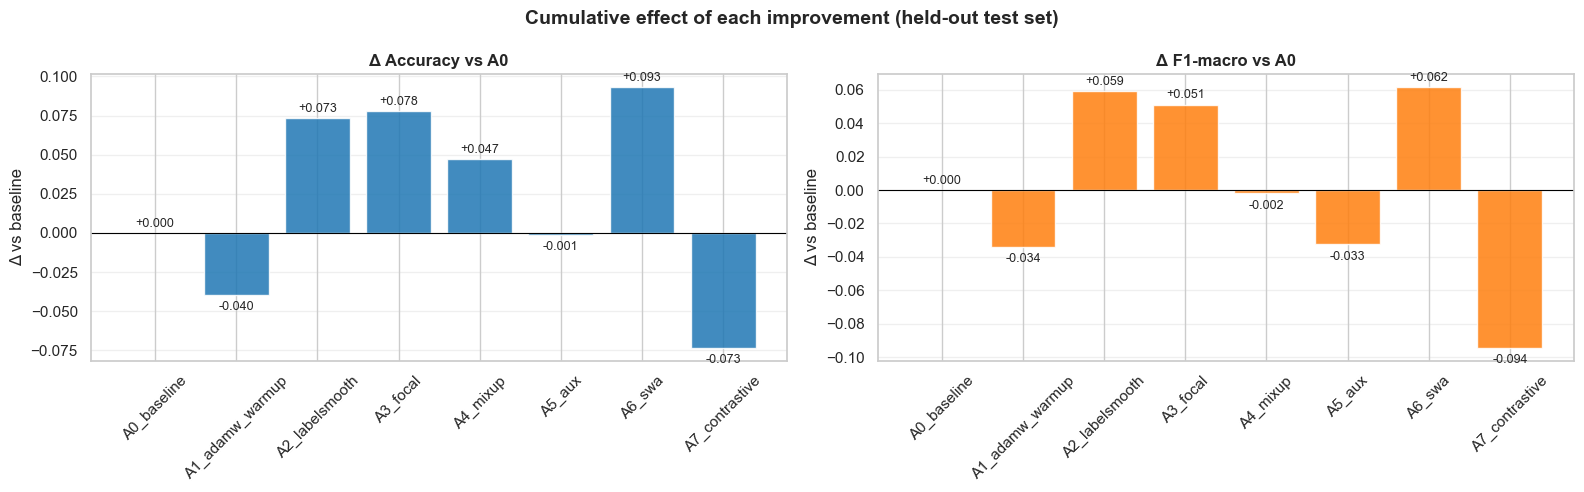

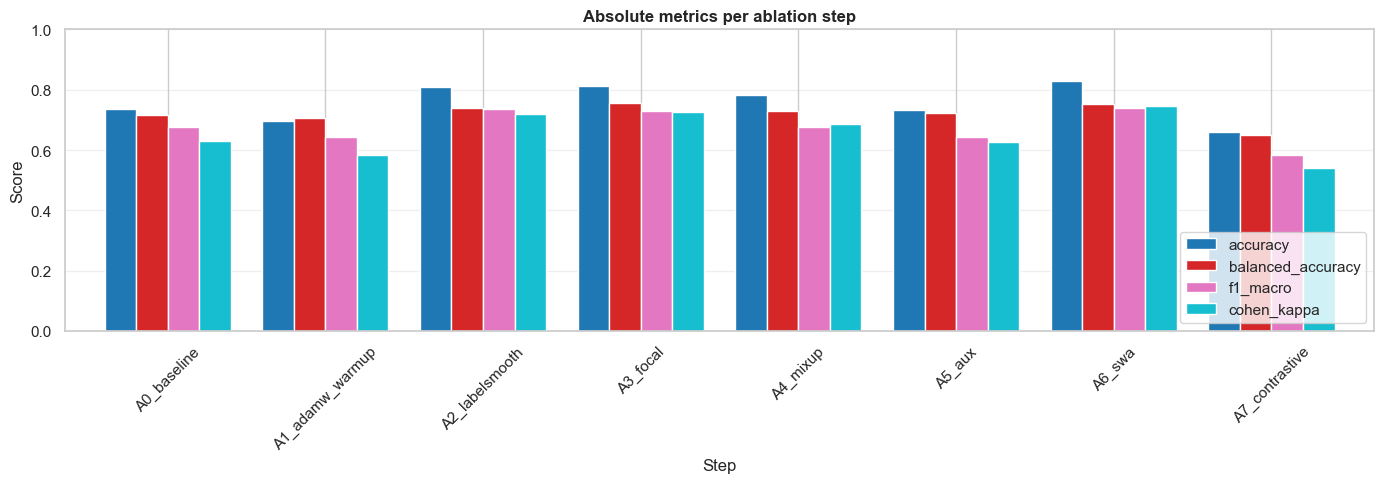

In [19]:
# ── Cumulative delta vs A0 baseline ──────────────────────────────────────────
if len(df_cmp) >= 2:
    base = df_cmp.iloc[0]
    steps = list(df_cmp.index)
    d_acc = (df_cmp['accuracy']   - base['accuracy']).values
    d_f1  = (df_cmp['f1_macro']   - base['f1_macro']).values

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, delta, title, color in [
        (axes[0], d_acc, 'Δ Accuracy vs A0',  '#1f77b4'),
        (axes[1], d_f1,  'Δ F1-macro vs A0',  '#ff7f0e')]:
        bars = ax.bar(steps, delta, color=color, alpha=0.85)
        ax.axhline(0, color='black', lw=0.8)
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel('Δ vs baseline'); ax.tick_params(axis='x', rotation=45)
        ax.grid(alpha=0.3, axis='y')
        for b, v in zip(bars, delta):
            ax.text(b.get_x() + b.get_width()/2, v + (0.002 if v >= 0 else -0.004),
                    f'{v:+.3f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
    plt.suptitle('Cumulative effect of each improvement (held-out test set)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    png_name = f'ablation_improved_delta_merged{SUFFIX}.png'
    plt.savefig(png_name, dpi=200, bbox_inches='tight')
    print(f'Saved {png_name}')
    plt.show()

    # Absolute metric bars
    fig2, ax2 = plt.subplots(figsize=(14, 5))
    df_cmp[['accuracy', 'balanced_accuracy', 'f1_macro', 'cohen_kappa']].plot(
        kind='bar', ax=ax2, rot=45, colormap='tab10', width=0.8)
    ax2.set_ylabel('Score'); ax2.set_ylim(0, 1)
    ax2.set_title('Absolute metrics per ablation step', fontweight='bold')
    ax2.legend(loc='lower right'); ax2.grid(alpha=0.3, axis='y')
    plt.tight_layout(); plt.show()
else:
    print('Need >=2 completed steps for the delta plot.')

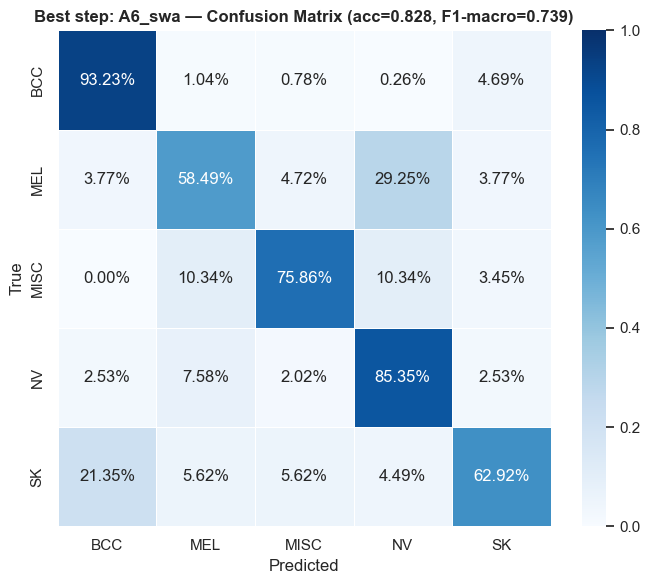

In [20]:
# ── Confusion matrix of the best step (by F1-macro) ──────────────────────────
if results:
    best_name = max(results, key=lambda k: results[k]['f1_macro'])
    best_ckpt = next(c['ckpt'] for c in ABLATIONS if c['name'] == best_name)
    m = build_eval_model(best_ckpt)
    preds, y = [], []
    with torch.no_grad():
        for clinic, derm, lb in test_loader:
            logits, _ = m(clinic.to(device), derm.to(device))
            preds.extend(logits.argmax(1).cpu().numpy()); y.extend(lb.numpy())
    cm = confusion_matrix(y, preds, labels=list(range(len(class_names))), normalize='true')
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', vmin=0, vmax=1,
                xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
    plt.title(f'Best step: {best_name} — Confusion Matrix '
              f"(acc={results[best_name]['accuracy']:.3f}, "
              f"F1-macro={results[best_name]['f1_macro']:.3f})", fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout(); plt.show()
    del m
else:
    print('No completed steps to plot.')